### Task 1: Data Import and Initial Display

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Set random seed for reproducibility
np.random.seed(42)

In [18]:
# Dataset provided in the problem description
data = {
    'Student ID': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30],
    'Hours Studied': [10, 5, 3, 8, 7, 6, 2, 1, 9, 4, 6, 7, 8, 3, 5, 10, 2, 8, 9, 4, np.nan, 3, 2, 1, 9, 8, 7, 6, 5, 4],
    'Assignment Scores': [85, 60, 40, 80, 70, 65, 30, 20, np.nan, 50, 60, 75, 85, 45, 55, np.nan, 35, 85, 90, 55, 65, 40, 30, 25, 90, 80, 75, 70, 65, 60],
    'Class Participation': [8, 7, 5, 9, 6, 8, 4, 3, 10, 5, 7, 6, 9, 4, 6, 10, 3, 9, 10, 6, 7, 5, np.nan, 3, 9, 8, 7, 6, 5, 4],
    'Final Exam Score': [95, 78, 50, 90, 85, 88, 45, 40, 92, 55, 68, 75, 88, 48, 60, 98, 42, 89, 95, 58, 68, 55, 48, 42, 90, 85, 78, 70, 65, 60]
}

df = pd.DataFrame(data)

print("Initial few records of the dataset:")
display(df.head())

Initial few records of the dataset:


,Student ID,Hours Studied,Assignment Scores,Class Participation,Final Exam Score
0,1,10.0,85.0,8.0,95
1,2,5.0,60.0,7.0,78
2,3,3.0,40.0,5.0,50
3,4,8.0,80.0,9.0,90
4,5,7.0,70.0,6.0,85


### Task 2: Data Pre-processing (Missing Values)

In [19]:
# e) Remove missing values
df_cleaned = df.dropna()

print("Dataset after removing missing values:")
display(df_cleaned.head())

# f) Obtain the overall count of instances after excluding records with missing values
initial_rows = len(df)
cleaned_rows = len(df_cleaned)

print(f"\nInitial number of rows: {initial_rows}")
print(f"Number of rows after removing missing values: {cleaned_rows}")
print(f"Number of rows dropped: {initial_rows - cleaned_rows}")

Dataset after removing missing values:


,Student ID,Hours Studied,Assignment Scores,Class Participation,Final Exam Score
0,1,10.0,85.0,8.0,95
1,2,5.0,60.0,7.0,78
2,3,3.0,40.0,5.0,50
3,4,8.0,80.0,9.0,90
4,5,7.0,70.0,6.0,85



Initial number of rows: 30
Number of rows after removing missing values: 26
Number of rows dropped: 4


### Task 3: Splitting the Dataset

In [20]:
# g) Split the dataset into training and test sets
# Features (X) are all columns except 'Student ID' and 'Final Exam Score'
# Target (y) is 'Final Exam Score'
X = df_cleaned.drop(columns=['Student ID', 'Final Exam Score'])
y = df_cleaned['Final Exam Score']

# h) Adhere to either the 20-80 / 25-75 or the 30-70 policy. Using 70-30 split (test_size=0.3)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (18, 3)
Shape of X_test: (8, 3)
Shape of y_train: (18,)
Shape of y_test: (8,)


### Task 4: Implementing Decision Tree and Random Forest Models

In [21]:
# i) Implement Decision Tree Model
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)
dt_predictions = dt_model.predict(X_test)

# i) Implement Random Forest Model
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)

# j) Create DataFrames for forecasts and calculate metrics

# Decision Tree Results
dt_results_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': dt_predictions,
    'Residuals': y_test - dt_predictions
})

dt_mse = mean_squared_error(y_test, dt_predictions)
dt_r2 = r2_score(y_test, dt_predictions)

print("\n--- Decision Tree Model Results ---")
display(dt_results_df)
print(f"Mean Squared Error (MSE): {dt_mse:.2f}")
print(f"R-squared (R2): {dt_r2:.2f}")

# Random Forest Results
rf_results_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': rf_predictions,
    'Residuals': y_test - rf_predictions
})

rf_mse = mean_squared_error(y_test, rf_predictions)
rf_r2 = r2_score(y_test, rf_predictions)

print("\n--- Random Forest Model Results ---")
display(rf_results_df)
print(f"Mean Squared Error (MSE): {rf_mse:.2f}")
print(f"R-squared (R2): {rf_r2:.2f}")


--- Decision Tree Model Results ---


,Actual,Predicted,Residuals
9,55,52.5,2.5
18,95,90.0,5.0
0,95,85.0,10.0
28,65,70.0,-5.0
12,88,89.0,-1.0
10,68,58.0,10.0
14,60,58.0,2.0
1,78,58.0,20.0


Mean Squared Error (MSE): 82.66
R-squared (R2): 0.62

--- Random Forest Model Results ---


,Actual,Predicted,Residuals
9,55,55.932500,-0.932500
18,95,89.520000,5.480000
0,95,86.330000,8.670000
28,65,64.267500,0.732500
12,88,88.950000,-0.950000
10,68,68.100000,-0.100000
14,60,59.981667,0.018333
1,78,61.156667,16.843333


Mean Squared Error (MSE): 48.90
R-squared (R2): 0.78


### Task 5: Visualizing Model Outcomes

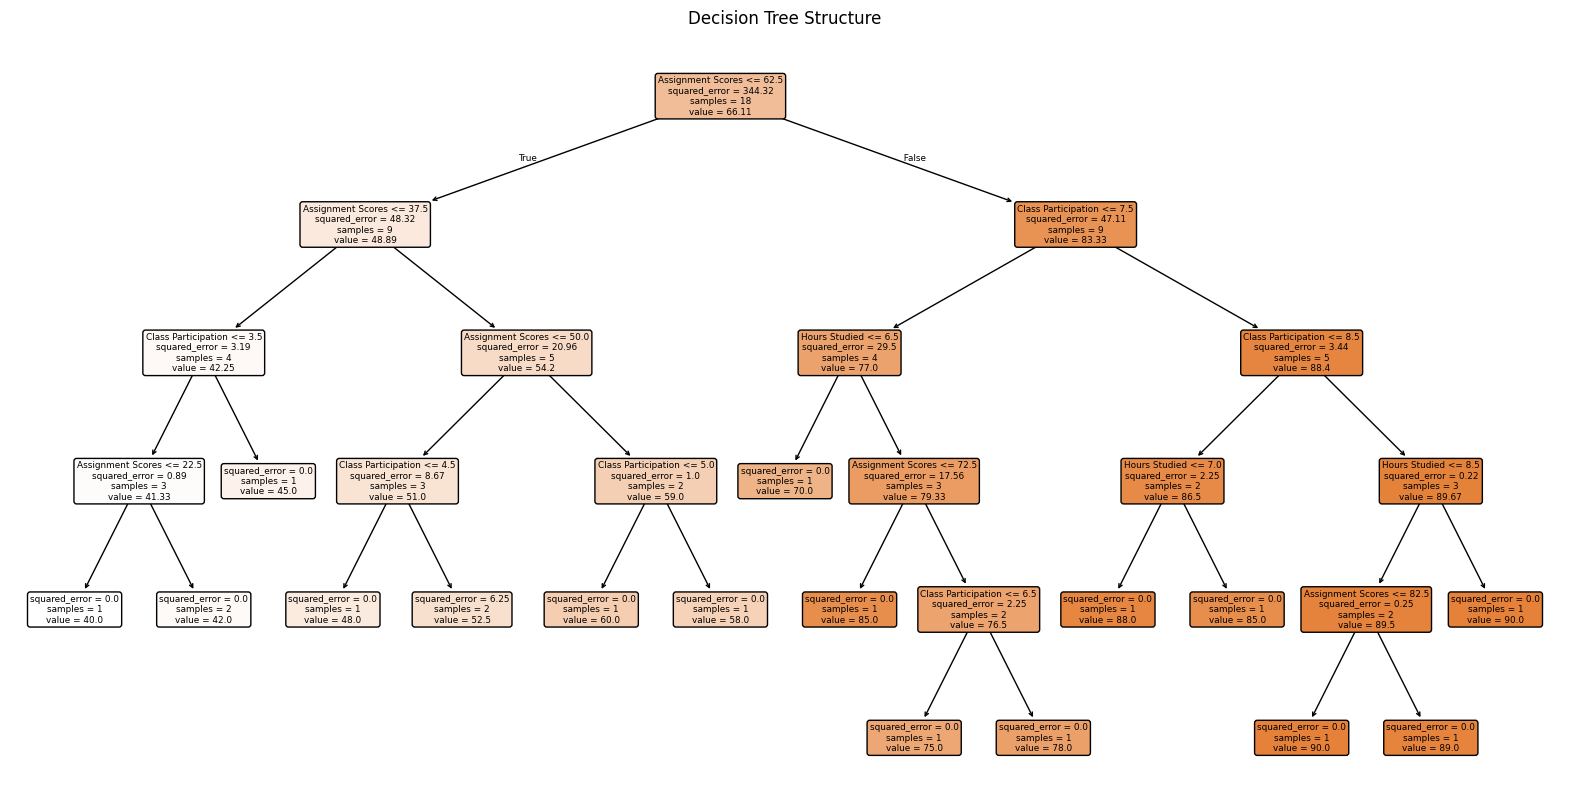

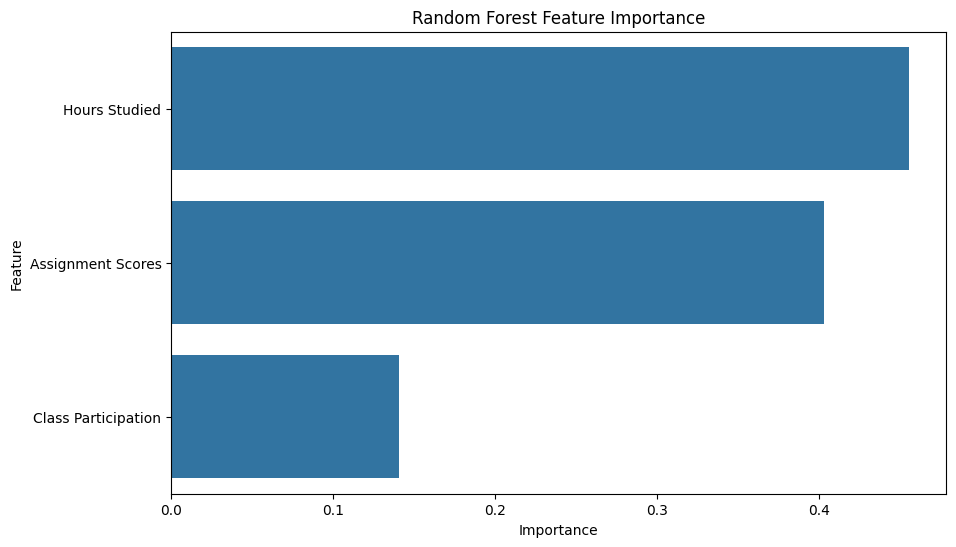

In [22]:
# l) Apply graphical tools for Decision Tree
plt.figure(figsize=(20,10))
plot_tree(dt_model, filled=True, feature_names=X.columns, rounded=True, precision=2)
plt.title("Decision Tree Structure")
plt.show()

# l) Apply graphical tools for Random Forest (Feature Importance)
feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances, y=feature_importances.index)
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

### Task 6: Reporting and Analysis

In [23]:
# Displaying key metrics again for easy reference in the report
print("\n--- Decision Tree Model Performance ---")
print(f"Mean Squared Error (MSE): {dt_mse:.2f}")
print(f"R-squared (R2): {dt_r2:.2f}")

print("\n--- Random Forest Model Performance ---")
print(f"Mean Squared Error (MSE): {rf_mse:.2f}")
print(f"R-squared (R2): {rf_r2:.2f}")

print("\n--- Random Forest Feature Importance ---")
display(feature_importances)


--- Decision Tree Model Performance ---
Mean Squared Error (MSE): 82.66
R-squared (R2): 0.62

--- Random Forest Model Performance ---
Mean Squared Error (MSE): 48.90
R-squared (R2): 0.78

--- Random Forest Feature Importance ---


,0
Hours Studied,0.455955
Assignment Scores,0.403243
Class Participation,0.140802


#### Analysis Report

This lab explored predicting 'Final Exam Score' using student data ('Hours Studied', 'Assignment Scores', 'Class Participation') through Decision Tree and Random Forest Regression models. The dataset started with 30 student records, which was reduced to 26 after dropping entries with missing values to ensure data quality.

After splitting the cleaned data (70% training, 30% testing), both models were trained and evaluated. The Decision Tree model yielded an MSE of 82.66 and an R2 score of 0.62. In contrast, the Random Forest model performed noticeably better, achieving an MSE of 48.90 and a higher R2 score of 0.78. This suggests that the ensemble nature of the Random Forest, which combines multiple decision trees, helped reduce variance and improve predictive accuracy over a single Decision Tree.

Looking at feature importance from the Random Forest model, 'Hours Studied' was the most significant predictor of final exam scores. This was followed by 'Assignment Scores', with 'Class Participation' having the least impact. This makes sense intuitively, as the effort put into studying and assignment performance would logically be strong indicators of exam success.

In conclusion, the Random Forest model was more effective for this dataset.